In [34]:
# Librerías 

import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt

from pathlib import Path

from sklearn.model_selection import (
    train_test_split,
    GridSearchCV
)

from sklearn.pipeline import Pipeline

from sklearn.feature_extraction.text import (
    TfidfVectorizer
)

from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

In [35]:
# Cargando el dataset

ruta = Path(
    r"C:\Users\irwin\Downloads\amazon_review.csv"
)

df = pd.read_csv(ruta)

print("Dimensiones:")
print(df.shape)

display(df.head())

Dimensiones:
(4915, 12)


,reviewerID,asin,reviewerName,helpful,reviewText,overall,summary,unixReviewTime,reviewTime,day_diff,helpful_yes,total_vote
0,A3SBTW3WS4IQSN,B007WTAJTO,NaN,"[0, 0]",No issues.,4.0,Four Stars,1406073600,2014-07-23,138,0,0
1,A18K1ODH1I2MVB,B007WTAJTO,0mie,"[0, 0]","Purchased this for my device, it worked as adv...",5.0,MOAR SPACE!!!,1382659200,2013-10-25,409,0,0
2,A2FII3I2MBMUIA,B007WTAJTO,1K3,"[0, 0]",it works as expected. I should have sprung for...,4.0,nothing to really say....,1356220800,2012-12-23,715,0,0
3,A3H99DFEG68SR,B007WTAJTO,1m2,"[0, 0]",This think has worked out great.Had a diff. br...,5.0,Great buy at this price!!! *** UPDATE,1384992000,2013-11-21,382,0,0
4,A375ZM4U047O79,B007WTAJTO,2&amp;1/2Men,"[0, 0]","Bought it with Retail Packaging, arrived legit...",5.0,best deal around,1373673600,2013-07-13,513,0,0


In [36]:
# Seleccionando las columnas de interés

datos = df[
    [
        "reviewText",
        "overall"
    ]
].copy()

display(datos.head())

,reviewText,overall
0,No issues.,4.0
1,"Purchased this for my device, it worked as adv...",5.0
2,it works as expected. I should have sprung for...,4.0
3,This think has worked out great.Had a diff. br...,5.0
4,"Bought it with Retail Packaging, arrived legit...",5.0


In [37]:
# Limpieando los datos

datos = datos.dropna(
    subset=[
        "reviewText",
        "overall"
    ]
).copy()

datos["reviewText"] = (
    datos["reviewText"]
    .astype(str)
)

datos["overall"] = pd.to_numeric(
    datos["overall"],
    errors="coerce"
)

datos = datos.dropna()

datos = datos.reset_index(
    drop=True
)

print(
    "Número de reseñas:",
    len(datos)
)

Número de reseñas: 4914


In [38]:
# Crear variable objetivo

def clasificar_sentimiento(rating):

    if rating <= 2:
        return "Negativo"

    elif rating == 3:
        return "Neutral"

    else:
        return "Positivo"

datos["sentimiento"] = (
    datos["overall"]
    .apply(clasificar_sentimiento)
)

display(
    datos[
        [
            "reviewText",
            "overall",
            "sentimiento"
        ]
    ].head(10)
)

,reviewText,overall,sentimiento
0,No issues.,4.0,Positivo
1,"Purchased this for my device, it worked as adv...",5.0,Positivo
2,it works as expected. I should have sprung for...,4.0,Positivo
3,This think has worked out great.Had a diff. br...,5.0,Positivo
4,"Bought it with Retail Packaging, arrived legit...",5.0,Positivo
5,It's mini storage. It doesn't do anything els...,5.0,Positivo
6,I have it in my phone and it never skips a bea...,5.0,Positivo
7,It's hard to believe how affordable digital ha...,5.0,Positivo
8,Works in a HTC Rezound. Was running short of ...,5.0,Positivo
9,"in my galaxy s4, super fast card, and am total...",5.0,Positivo


In [39]:
# Distribución de clases

distribucion = (
    datos["sentimiento"]
    .value_counts()
)

display(distribucion)

sentimiento
Positivo    4448
Negativo     324
Neutral      142
Name: count, dtype: int64

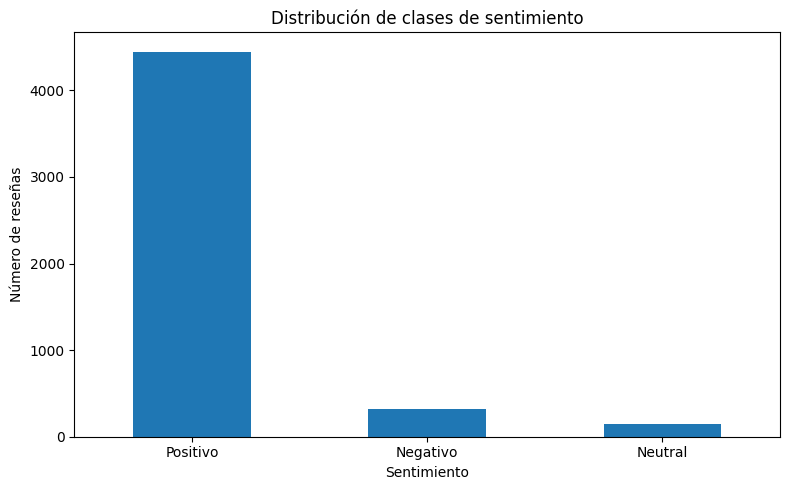

In [40]:
# Gráficas de sentimientos

plt.figure(
    figsize=(8, 5)
)

distribucion.plot(
    kind="bar"
)

plt.title(
    "Distribución de clases de sentimiento"
)

plt.xlabel(
    "Sentimiento"
)

plt.ylabel(
    "Número de reseñas"
)

plt.xticks(
    rotation=0
)

plt.tight_layout()

plt.show()

In [41]:
# Reseñas 

def limpiar_texto(texto):

    texto = str(texto).lower()

    # Eliminar URLs
    texto = re.sub(
        r"http\S+|www\S+",
        " ",
        texto
    )

    # Eliminar etiquetas HTML
    texto = re.sub(
        r"<.*?>",
        " ",
        texto
    )

    # Conservar solo letras
    texto = re.sub(
        r"[^a-z\s]",
        " ",
        texto
    )

    # Eliminar espacios repetidos
    texto = re.sub(
        r"\s+",
        " ",
        texto
    )

    return texto.strip()

datos["texto_limpio"] = (
    datos["reviewText"]
    .apply(limpiar_texto)
)

display(
    datos[
        [
            "reviewText",
            "texto_limpio"
        ]
    ].head()
)

,reviewText,texto_limpio
0,No issues.,no issues
1,"Purchased this for my device, it worked as adv...",purchased this for my device it worked as adve...
2,it works as expected. I should have sprung for...,it works as expected i should have sprung for ...
3,This think has worked out great.Had a diff. br...,this think has worked out great had a diff bra...
4,"Bought it with Retail Packaging, arrived legit...",bought it with retail packaging arrived legit ...


In [42]:
# Eliminación de textos vacíos después de la limpieza

datos = datos[
    datos["texto_limpio"].str.len() > 0
].copy()

datos = datos.reset_index(
    drop=True
)

print(
    "Total final:",
    len(datos)
)

Total final: 4914


In [43]:
# Definir variables predictoras y objetivo

X = datos[
    "texto_limpio"
]

y = datos[
    "sentimiento"
]

In [17]:
# Train-test split

X_train, X_test, y_train, y_test = (
    train_test_split(
        X,
        y,
        test_size=0.20,
        random_state=42,
        stratify=y
    )
)

print(
    "Entrenamiento:",
    len(X_train)
)

print(
    "Prueba:",
    len(X_test)
)

Entrenamiento: 3931
Prueba: 983


In [18]:
# Diseño experimental

experimentos = [

    # REGRESIÓN LOGÍSTICA

    {
        "nombre":
        "Regresión Logística",

        "pipeline":
        Pipeline([

            (
                "tfidf",
                TfidfVectorizer(
                    stop_words="english"
                )
            ),

            (
                "modelo",
                LogisticRegression(
                    max_iter=2000,
                    class_weight="balanced",
                    random_state=42
                )
            )

        ]),

        "parametros": {

            "tfidf__ngram_range": [
                (1, 1),
                (1, 2)
            ],

            "tfidf__max_features": [
                1000,
                3000,
                5000
            ],

            "modelo__C": [
                0.1,
                1,
                10
            ]
        }
    },
  # NAIVE BAYES
   
    {
        "nombre":
        "Naive Bayes",

        "pipeline":
        Pipeline([

            (
                "tfidf",
                TfidfVectorizer(
                    stop_words="english"
                )
            ),

            (
                "modelo",
                MultinomialNB()
            )

        ]),

        "parametros": {

            "tfidf__ngram_range": [
                (1, 1),
                (1, 2)
            ],

            "tfidf__max_features": [
                1000,
                3000,
                5000
            ],

            "modelo__alpha": [
                0.1,
                0.5,
                1.0
            ]
        }
    },
    # SVM LINEAL

    {
        "nombre":
        "SVM Lineal",

        "pipeline":
        Pipeline([

            (
                "tfidf",
                TfidfVectorizer(
                    stop_words="english"
                )
            ),

            (
                "modelo",
                LinearSVC(
                    class_weight="balanced",
                    random_state=42
                )
            )

        ]),

        "parametros": {

            "tfidf__ngram_range": [
                (1, 1),
                (1, 2)
            ],

            "tfidf__max_features": [
                1000,
                3000,
                5000
            ],

            "modelo__C": [
                0.1,
                1,
                10
            ]
        }
    }
]

In [19]:
# Ejecicón de experimentos

resultados_cv = []

mejores_modelos = {}

for experimento in experimentos:

    print(
        "\n",
        "=" * 70
    )

    print(
        experimento["nombre"]
    )

    print(
        "=" * 70
    )

    grid = GridSearchCV(

        estimator=
        experimento["pipeline"],

        param_grid=
        experimento["parametros"],

        scoring=
        "f1_macro",

        cv=5,

        n_jobs=-1,

        verbose=1
    )

    grid.fit(
        X_train,
        y_train
    )

    mejores_modelos[
        experimento["nombre"]
    ] = grid.best_estimator_

    resultados_cv.append({

        "Modelo":
        experimento["nombre"],

        "Mejor F1 CV":
        grid.best_score_,

        "Mejores parámetros":
        str(
            grid.best_params_
        )
    })

    print(
        "\nMejor F1:",
        round(
            grid.best_score_,
            4
        )
    )

    print(
        "Mejores parámetros:"
    )

    print(
        grid.best_params_
    )


Regresión Logística
Fitting 5 folds for each of 18 candidates, totalling 90 fits

Mejor F1: 0.5814
Mejores parámetros:
{'modelo__C': 10, 'tfidf__max_features': 5000, 'tfidf__ngram_range': (1, 1)}

Naive Bayes
Fitting 5 folds for each of 18 candidates, totalling 90 fits

Mejor F1: 0.4932
Mejores parámetros:
{'modelo__alpha': 0.1, 'tfidf__max_features': 3000, 'tfidf__ngram_range': (1, 2)}

SVM Lineal
Fitting 5 folds for each of 18 candidates, totalling 90 fits

Mejor F1: 0.5738
Mejores parámetros:
{'modelo__C': 1, 'tfidf__max_features': 3000, 'tfidf__ngram_range': (1, 2)}


In [20]:
# Tabla de resultados de validación cruzada

df_resultados_cv = pd.DataFrame(
    resultados_cv
)

df_resultados_cv[
    "Mejor F1 CV"
] = (
    df_resultados_cv[
        "Mejor F1 CV"
    ]
    .round(4)
)

display(
    df_resultados_cv
)

,Modelo,Mejor F1 CV,Mejores parámetros
0,Regresión Logística,0.5814,"{'modelo__C': 10, 'tfidf__max_features': 5000,..."
1,Naive Bayes,0.4932,"{'modelo__alpha': 0.1, 'tfidf__max_features': ..."
2,SVM Lineal,0.5738,"{'modelo__C': 1, 'tfidf__max_features': 3000, ..."


In [21]:
# Evaluación con test

resultados_test = []

for nombre, modelo in mejores_modelos.items():

    predicciones = modelo.predict(
        X_test
    )

    accuracy = accuracy_score(
        y_test,
        predicciones
    )

    precision = precision_score(
        y_test,
        predicciones,
        average="macro",
        zero_division=0
    )

    recall = recall_score(
        y_test,
        predicciones,
        average="macro",
        zero_division=0
    )

    f1 = f1_score(
        y_test,
        predicciones,
        average="macro",
        zero_division=0
    )

    resultados_test.append({

        "Modelo": nombre,

        "Accuracy": accuracy,

        "Precision": precision,

        "Recall": recall,

        "F1-score": f1
    })

In [22]:
# Tabla comparativa 

df_resultados_test = pd.DataFrame(
    resultados_test
)

columnas_metricas = [
    "Accuracy",
    "Precision",
    "Recall",
    "F1-score"
]

df_resultados_test[
    columnas_metricas
] = (
    df_resultados_test[
        columnas_metricas
    ]
    .round(4)
)

display(
    df_resultados_test
)

,Modelo,Accuracy,Precision,Recall,F1-score
0,Regresión Logística,0.9135,0.5550,0.5495,0.5517
1,Naive Bayes,0.9329,0.5710,0.5051,0.5298
2,SVM Lineal,0.9278,0.5835,0.5433,0.5524


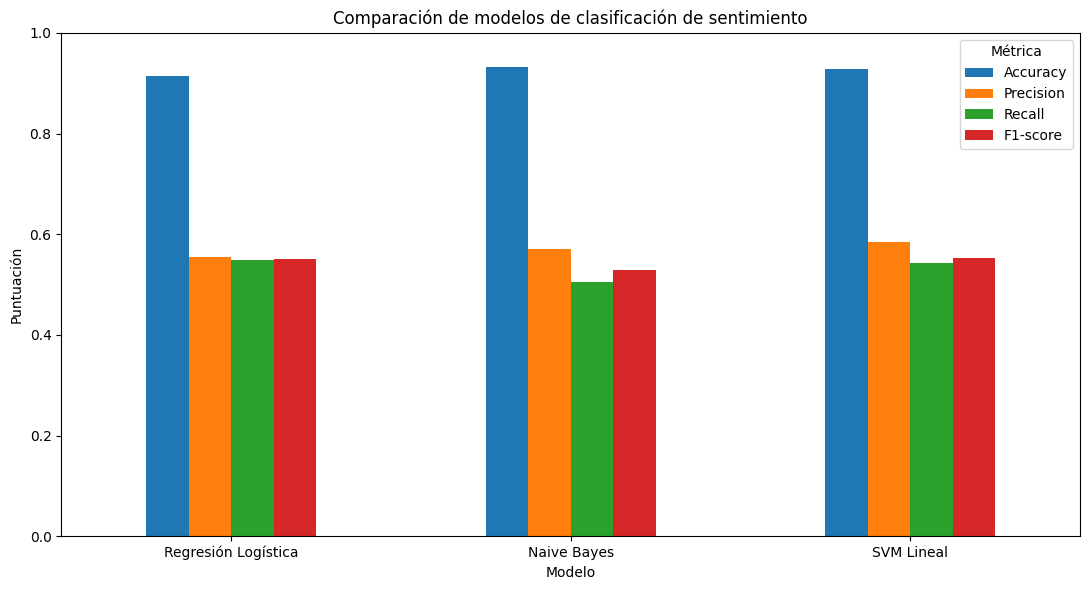

In [23]:
# Gráficas comparativa 

df_grafica = (
    df_resultados_test
    .set_index(
        "Modelo"
    )
)

df_grafica.plot(
    kind="bar",
    figsize=(11, 6)
)

plt.title(
    "Comparación de modelos de clasificación de sentimiento"
)

plt.ylabel(
    "Puntuación"
)

plt.xlabel(
    "Modelo"
)

plt.ylim(
    0,
    1
)

plt.xticks(
    rotation=0
)

plt.legend(
    title="Métrica"
)

plt.tight_layout()

plt.show()

In [24]:
# Elegir el mejor modelo 

mejor_fila = (
    df_resultados_test
    .sort_values(
        "F1-score",
        ascending=False
    )
    .iloc[0]
)

mejor_nombre = (
    mejor_fila[
        "Modelo"
    ]
)

print(
    "Mejor modelo:",
    mejor_nombre
)

print(
    "F1-score:",
    mejor_fila[
        "F1-score"
    ]
)

Mejor modelo: SVM Lineal
F1-score: 0.5524


In [25]:
# Reporte de la mejor clasificación 

mejor_modelo = mejores_modelos[
    mejor_nombre
]

predicciones_finales = (
    mejor_modelo.predict(
        X_test
    )
)

print(
    classification_report(
        y_test,
        predicciones_finales,
        digits=4,
        zero_division=0
    )
)


              precision    recall  f1-score   support

    Negativo     0.6557    0.6154    0.6349        65
     Neutral     0.1429    0.0357    0.0571        28
    Positivo     0.9519    0.9787    0.9651       890

    accuracy                         0.9278       983
   macro avg     0.5835    0.5433    0.5524       983
weighted avg     0.9093    0.9278    0.9174       983



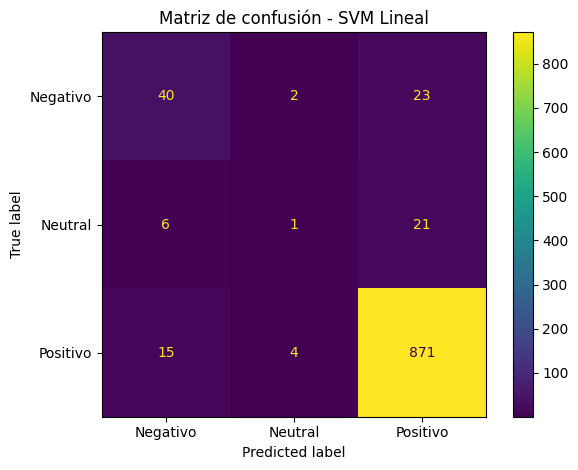

In [26]:
# Matriz 

clases = [
    "Negativo",
    "Neutral",
    "Positivo"
]

matriz = confusion_matrix(
    y_test,
    predicciones_finales,
    labels=clases
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=matriz,
    display_labels=clases
)

disp.plot()

plt.title(
    f"Matriz de confusión - {mejor_nombre}"
)

plt.tight_layout()

plt.show()